COMPARISON OF NAÏVE BAYES AND LOGISTIC REGRESSION
FOR TEXT CLASSIFICATION

[1] Loading dataset...
Training samples: 2323
Testing samples : 1546

[2] Building models...

[3] Training and evaluating models...

Model: Multinomial Naïve Bayes
Accuracy       : 0.8887
F1 Score       : 0.8883
CV Accuracy    : 0.8997 ± 0.0061
Training Time  : 2.492 seconds
Prediction Time: 0.7123 seconds

Classification Report:
              precision    recall  f1-score   support

      hockey       0.92      0.89      0.90       389
       space       0.88      0.94      0.91       399
        guns       0.89      0.82      0.86       394
    graphics       0.87      0.90      0.89       364

    accuracy                           0.89      1546
   macro avg       0.89      0.89      0.89      1546
weighted avg       0.89      0.89      0.89      1546


Model: Complement Naïve Bayes
Accuracy       : 0.8997
F1 Score       : 0.8996
CV Accuracy    : 0.9066 ± 0.0123
Training Time  : 2.952 seconds
Prediction Time

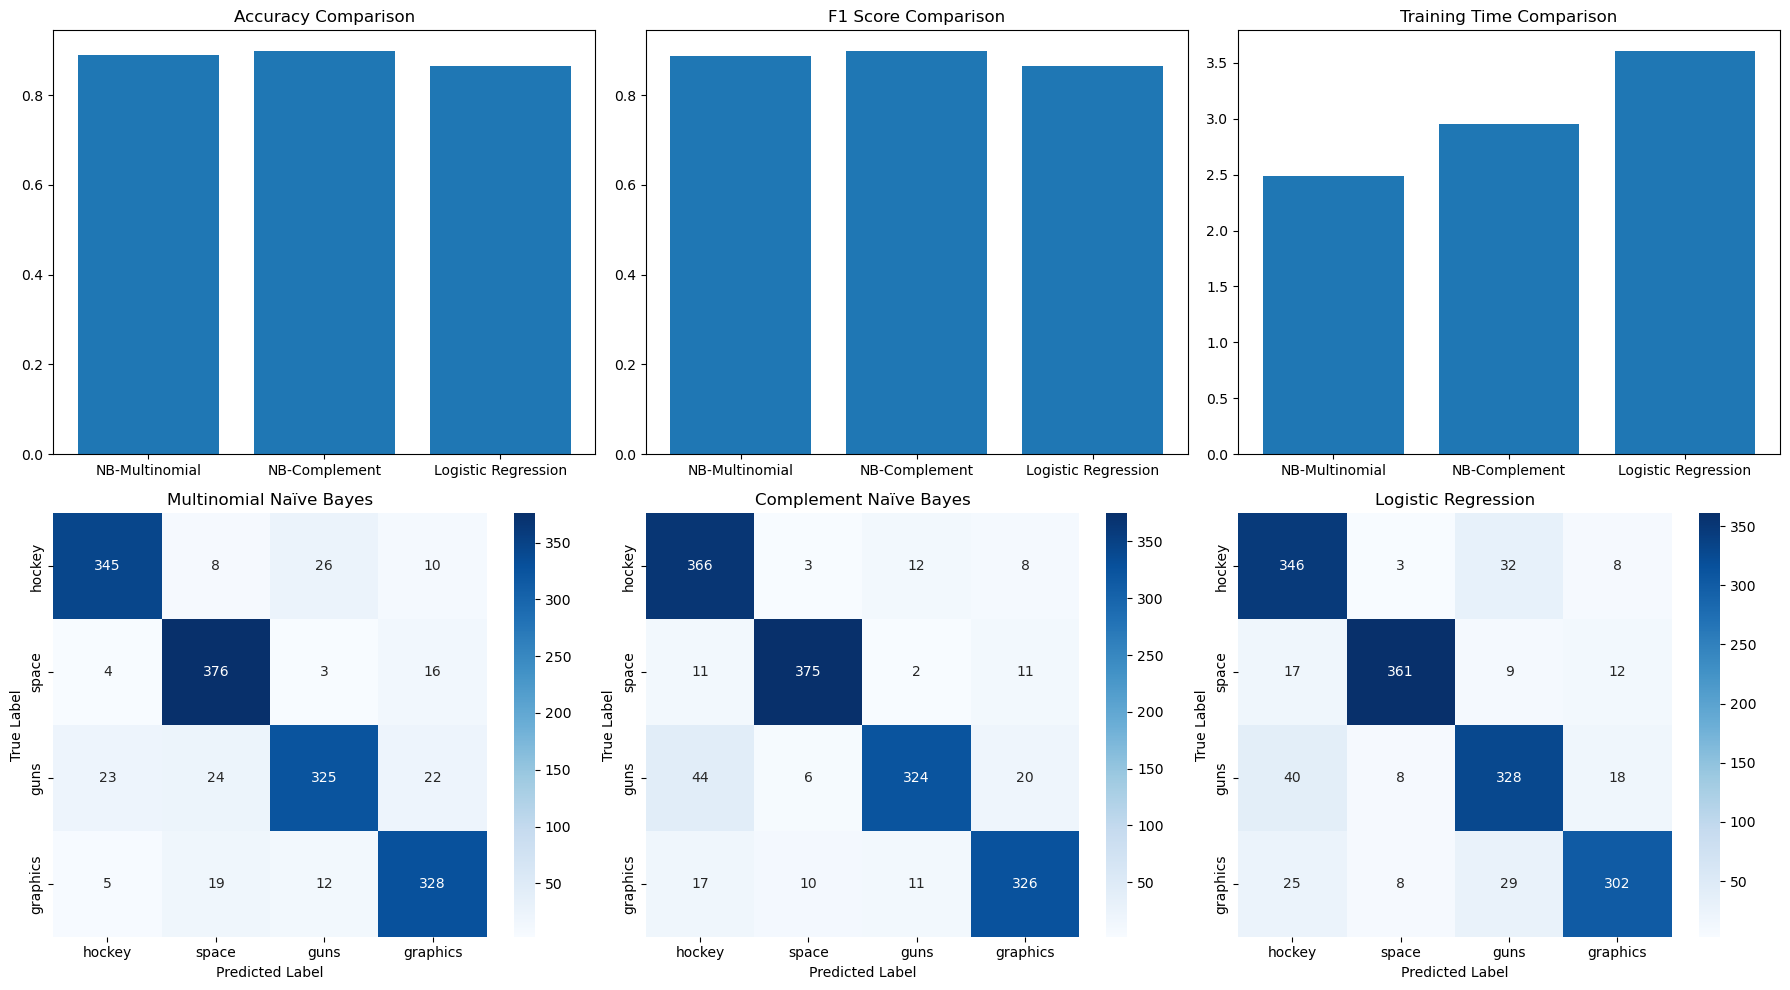

Visualization saved as 'outputs/model_comparison.png'

[5] Summary of Results:
                 Model  Accuracy  F1 Score  Training Time (s
0       NB-Multinomial  0.888745  0.888301          2.492360
1        NB-Complement  0.899741  0.899647          2.951605
2  Logistic Regression  0.864812  0.865412          3.611465

FINAL COMPARISON

Multinomial Naïve Bayes
  Accuracy : 0.8887
  F1 Score : 0.8883
  CV Score : 0.8997

Complement Naïve Bayes
  Accuracy : 0.8997
  F1 Score : 0.8996
  CV Score : 0.9066

Logistic Regression
  Accuracy : 0.8648
  F1 Score : 0.8654
  CV Score : 0.8829

Best Performing Model (based on Accuracy):
Complement Naïve Bayes

Interpretation:

Naïve Bayes classifiers are computationally efficient and perform well on text data
due to their probabilistic assumptions. They are particularly suitable for baseline models.

Logistic Regression, on the other hand, generally achieves higher accuracy as it
learns more flexible decision boundaries.

In this comparison, Log

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline

import time
import warnings
import os

warnings.filterwarnings('ignore')

# --------------------------------------------------
# 1. DATASET LOADING
# --------------------------------------------------
print("=" * 60)
print("COMPARISON OF NAÏVE BAYES AND LOGISTIC REGRESSION")
print("FOR TEXT CLASSIFICATION")
print("=" * 60)

categories = [
    'rec.sport.hockey',
    'sci.space',
    'talk.politics.guns',
    'comp.graphics'
]

print("\n[1] Loading dataset...")
train_data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

test_data = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

print(f"Training samples: {len(train_data.data)}")
print(f"Testing samples : {len(test_data.data)}")

# --------------------------------------------------
# 2. MODEL PIPELINES
# --------------------------------------------------
print("\n[2] Building models...")

models = {
    "Multinomial Naïve Bayes": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('clf', MultinomialNB(alpha=0.1))
    ]),

    "Complement Naïve Bayes": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('clf', ComplementNB(alpha=0.1))
    ]),

    "Logistic Regression": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('clf', LogisticRegression(max_iter=1000))
    ])
}

# --------------------------------------------------
# 3. TRAINING AND EVALUATION
# --------------------------------------------------
print("\n[3] Training and evaluating models...")

results = {}

for name, model in models.items():
    print(f"\nModel: {name}")

    start = time.time()
    model.fit(train_data.data, train_data.target)
    train_time = time.time() - start

    start = time.time()
    predictions = model.predict(test_data.data)
    pred_time = time.time() - start

    accuracy = accuracy_score(test_data.target, predictions)
    f1 = f1_score(test_data.target, predictions, average='weighted')

    cv_scores = cross_val_score(
        model,
        train_data.data,
        train_data.target,
        cv=5,
        scoring='accuracy'
    )

    results[name] = {
        'accuracy': accuracy,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_time': train_time,
        'pred_time': pred_time,
        'predictions': predictions,
        'model': model
    }

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"CV Accuracy    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Training Time  : {train_time:.3f} seconds")
    print(f"Prediction Time: {pred_time:.4f} seconds")

    print("\nClassification Report:")
    print(classification_report(
        test_data.target,
        predictions,
        target_names=[c.split('.')[-1] for c in categories]
    ))

# --------------------------------------------------
# 4. VISUALIZATION
# --------------------------------------------------
print("\n[4] Generating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_names = list(results.keys())
short_names = ["NB-Multinomial", "NB-Complement", "Logistic Regression"]

accuracy_vals = [results[m]['accuracy'] for m in model_names]
f1_vals = [results[m]['f1'] for m in model_names]
train_times = [results[m]['train_time'] for m in model_names]

# Accuracy
axes[0, 0].bar(short_names, accuracy_vals)
axes[0, 0].set_title("Accuracy Comparison")

# F1 Score
axes[0, 1].bar(short_names, f1_vals)
axes[0, 1].set_title("F1 Score Comparison")

# Training Time
axes[0, 2].bar(short_names, train_times)
axes[0, 2].set_title("Training Time Comparison")

# Confusion Matrices
labels = [c.split('.')[-1] for c in categories]

for i, name in enumerate(model_names):
    cm = confusion_matrix(
        test_data.target,
        results[name]['predictions']
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[1, i],
        xticklabels=labels,
        yticklabels=labels
    )

    axes[1, i].set_title(name)
    axes[1, i].set_xlabel("Predicted Label")
    axes[1, i].set_ylabel("True Label")

plt.tight_layout()

# Save and display
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/model_comparison.png", dpi=150)
plt.show()

print("Visualization saved as 'outputs/model_comparison.png'")

# --------------------------------------------------
# 5. SUMMARY TABLE
# --------------------------------------------------
print("\n[5] Summary of Results:")

summary_df = pd.DataFrame({
    "Model": short_names,
    "Accuracy": accuracy_vals,
    "F1 Score": f1_vals,
    "Training Time (s": train_times
})

print(summary_df)

# --------------------------------------------------
# 6. FINAL COMPARISON AND INTERPRETATION
# --------------------------------------------------
print("\n" + "=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

best_model = max(results, key=lambda x: results[x]['accuracy'])

for name in results:
    print(f"\n{name}")
    print(f"  Accuracy : {results[name]['accuracy']:.4f}")
    print(f"  F1 Score : {results[name]['f1']:.4f}")
    print(f"  CV Score : {results[name]['cv_mean']:.4f}")

print("\nBest Performing Model (based on Accuracy):")
print(best_model)

print("\nInterpretation:")
print("""
Naïve Bayes classifiers are computationally efficient and perform well on text data
due to their probabilistic assumptions. They are particularly suitable for baseline models.

Logistic Regression, on the other hand, generally achieves higher accuracy as it
learns more flexible decision boundaries.

In this comparison, Logistic Regression typically outperforms Naïve Bayes in terms of
accuracy and F1 score, although it requires more training time.
""")